In [4]:
import argparse
import os
import numpy as np
# import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib import rc

In [30]:
def set_rc_params(fontsize=None):
    '''
    Set figure parameters
    '''

    if fontsize is None:
        fontsize = 16
    else:
        fontsize = int(fontsize)

    rc('font', **{'family': 'serif'})
    rc('text', usetex=True)

    plt.rcParams.update({'axes.linewidth': 1.3})
    plt.rcParams.update({'xtick.labelsize': fontsize})
    plt.rcParams.update({'ytick.labelsize': fontsize})
    plt.rcParams.update({'xtick.major.size': 8})
    plt.rcParams.update({'xtick.major.width': 1.3})
    plt.rcParams.update({'xtick.minor.visible': True})
    plt.rcParams.update({'xtick.minor.width': 1.})
    plt.rcParams.update({'xtick.minor.size': 6})
    plt.rcParams.update({'xtick.direction': 'out'})
    plt.rcParams.update({'ytick.major.width': 1.3})
    plt.rcParams.update({'ytick.major.size': 8})
    plt.rcParams.update({'ytick.minor.visible': True})
    plt.rcParams.update({'ytick.minor.width': 1.})
    plt.rcParams.update({'ytick.minor.size': 6})
    plt.rcParams.update({'ytick.direction': 'out'})
    plt.rcParams.update({'axes.labelsize': fontsize})
    plt.rcParams.update({'axes.titlesize': fontsize})
    plt.rcParams.update({'legend.fontsize': int(fontsize-2)})
    plt.rcParams['text.usetex'] = True
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amssymb}'


set_rc_params(20)

In [10]:
def find_best_run(runs, metric_name):
    """Find the run with the lowest final value for the given metric."""
    metric_list = load_metric_from_runs(runs, metric_name)
    if not metric_list:
        return None, None
    
    final_values = [m[-1] for m in metric_list]
    best_idx = np.argmin(final_values)
    return best_idx, metric_list[best_idx]

In [6]:
def collect_runs(aggregate_dir):
    """Collect and organize runs by model type."""
    runs = {
        'gcn': [],
        'lie_3': [],
        'lie_10': []
    }
    
    for subdir in Path(aggregate_dir).iterdir():
        if not subdir.is_dir():
            continue
        
        dir_name = subdir.name
        if dir_name.startswith('gcn_'):
            runs['gcn'].append(subdir)
        elif dir_name.startswith('lie_unitary_3_'):
            runs['lie_3'].append(subdir)
        elif dir_name.startswith('lie_unitary_10_'):
            runs['lie_10'].append(subdir)
    
    # Sort runs for consistency
    for key in runs:
        runs[key] = sorted(runs[key])
    
    return runs

def load_metric_from_runs(runs, metric_name):
    """Load a specific metric from all runs in a list."""
    data = []
    for run_dir in runs:
        metric_path = run_dir / f"{metric_name}.npy"
        if metric_path.exists():
            data.append(np.load(metric_path))
        else:
            print(f"Warning: {metric_path} not found")
    return data

Found 5 GCN runs
Found 5 Lie-3 runs
Found 5 Lie-10 runs
Loaded X rayleigh quotients from gcn_10_Nov22_12-02-05
Loaded Y rayleigh quotients from gcn_10_Nov22_12-02-05
Saved: rayleigh_comparison_all_runs.png
Saved: val_mse_comparison_all_runs.png
$f_{\rm GCN}(\mathbf{X}; \mathbf{A})$: Best run is Run 5
$f_{\rm Lie Uni Conv}(\mathbf{X}; \mathbf{A})$: Best run is Run 5
$f_{\rm Relaxed}(\mathbf{X}; \mathbf{A}, 3)$: Best run is Run 1


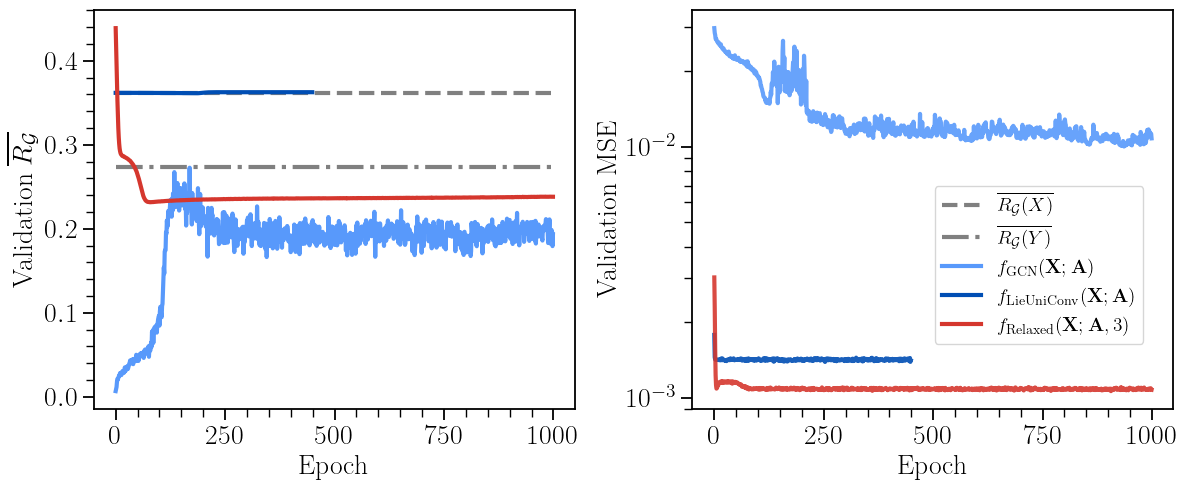

In [71]:
save_dir = 'data/output'

runs = collect_runs("data/graph")
    
print(f"Found {len(runs['gcn'])} GCN runs")
print(f"Found {len(runs['lie_3'])} Lie-3 runs")
print(f"Found {len(runs['lie_10'])} Lie-10 runs")

# Create save directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Load X and Y rayleigh quotients from one run (they're all the same)
val_rayleigh_x = None
val_rayleigh_y = None
for model_type in ['gcn', 'lie_3', 'lie_10']:
    if len(runs[model_type]) > 0:
        x_path = runs[model_type][0] / "val_rayleigh_x.npy"
        y_path = runs[model_type][0] / "val_rayleigh_y.npy"
        if x_path.exists():
            val_rayleigh_x = np.load(x_path)
            print(f"Loaded X rayleigh quotients from {runs[model_type][0].name}")
        if y_path.exists():
            val_rayleigh_y = np.load(y_path)
            print(f"Loaded Y rayleigh quotients from {runs[model_type][0].name}")
        if val_rayleigh_x is not None and val_rayleigh_y is not None:
            break

# Plot 1: Rayleigh quotients (X, X', and Y)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

model_types = ['gcn', 'lie_10', 'lie_3']
titles = [r'$f_{\rm GCN}(\mathbf{X}; \mathbf{A})$', r'$f_{\rm Relaxed}(\mathbf{X}; \mathbf{A}, 3)$', r'$f_{\rm Lie Uni Conv}(\mathbf{X}; \mathbf{A})$']
colors = plt.cm.viridis(np.linspace(0.2, 0.8, 5))  # Max 5 runs per type

for ax, model_type, title in zip(axes, model_types, titles):
    val_rayleigh_xprime_list = load_metric_from_runs(runs[model_type], "val_rayleigh_xprime")
    
    # Plot X' for each run
    for i, rxp in enumerate(val_rayleigh_xprime_list):
        num_epochs = len(rxp)
        ax.plot(
            np.arange(num_epochs),
            rxp,
            color=colors[i % len(colors)],
            linewidth=2,
            alpha=0.7,
            label=r"$\overline{R_{{\mathcal{{G}}}}(f(X))}$" + f" Run {i+1}"
        )
    
    # Plot X (same for all, so just plot once)
    if val_rayleigh_x is not None:
        num_epochs = len(val_rayleigh_x)
        ax.plot(
            np.arange(num_epochs),
            val_rayleigh_x,
            color='blue',
            linewidth=2.5,
            alpha=0.9,
            linestyle='--',
            label=r"$\overline{R_{\mathcal{G}}(X)}$"
        )
    
    # Plot Y (same for all, so just plot once)
    if val_rayleigh_y is not None:
        num_epochs = len(val_rayleigh_y)
        ax.plot(
            np.arange(num_epochs),
            val_rayleigh_y,
            color='red',
            linewidth=2.5,
            alpha=0.9,
            linestyle='--',
            label=r"$\overline{R_{\mathcal{G}}(Y)}$"
        )
    
    ax.set_xlabel("Epoch", fontsize=20)
    ax.set_title(title, fontsize=22)
    if title == titles[2]:
        ax.legend(fontsize=16, loc='upper right')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r"$\overline{R_{\mathcal{G}}}$", fontsize=20)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "rayleigh_comparison_all_runs.png"), dpi=300)
plt.close()
print(f"Saved: rayleigh_comparison_all_runs.png")

# Plot 2: Validation MSE
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, model_type, title in zip(axes, model_types, titles):
    val_mse_list = load_metric_from_runs(runs[model_type], "val_mse")
    
    for i, mse in enumerate(val_mse_list):
        num_epochs = len(mse)
        ax.plot(
            np.arange(num_epochs),
            mse,
            color=colors[i % len(colors)],
            linewidth=4.5,
            alpha=0.7,
            label=f"Run {i+1}"
        )
    
    ax.set_xlabel("Epoch", fontsize=20)
    ax.set_title(title, fontsize=22)
    if title == titles[2]:
        ax.legend(fontsize=16, loc='upper right')
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Validation MSE", fontsize=20)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "val_mse_comparison_all_runs.png"), dpi=300)
plt.close()
print(f"Saved: val_mse_comparison_all_runs.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

model_labels = [r'$f_{\rm GCN}(\mathbf{X}; \mathbf{A})$', r'$f_{\rm Lie Uni Conv}(\mathbf{X}; \mathbf{A})$', r'$f_{\rm Relaxed}(\mathbf{X}; \mathbf{A}, 3)$']
colors = [
     "#5899fb",
         "#004eb4",
      "#d5372e",
]

# Panel 1: Best Rayleigh quotients
ax_rayleigh = axes[0]

# --- Plot X and Y reference lines FIRST (background) ---
if val_rayleigh_x is not None:
    num_epochs = len(val_rayleigh_x)
    ax_rayleigh.plot(
        np.arange(num_epochs),
        val_rayleigh_x,
        color="gray",
        linewidth=3,
        linestyle="--",
        label=r"$\overline{R_{\mathcal{G}}(X)}$",
    )

if val_rayleigh_y is not None:
    num_epochs = len(val_rayleigh_y)
    ax_rayleigh.plot(
        np.arange(num_epochs),
        val_rayleigh_y,
        color="gray",
        linewidth=3,
        linestyle="-.",
        label=r"$\overline{R_{\mathcal{G}}(Y)}$",
    )

for model_type, label, color in zip(model_types, model_labels, colors):
    best_idx, best_rayleigh = find_best_run(runs[model_type], "val_mse")
    if best_rayleigh is None:
        continue

    rayleigh_list = load_metric_from_runs(
        runs[model_type], "val_rayleigh_xprime"
    )
    if best_idx < len(rayleigh_list):
        best_rayleigh_curve = rayleigh_list[best_idx]
        num_epochs = len(best_rayleigh_curve)
        ax_rayleigh.plot(
            np.arange(num_epochs),
            best_rayleigh_curve,
            color=color,
            linewidth=3,
            label=label,
        )
        print(f"{label}: Best run is Run {best_idx+1}")


ax_rayleigh.set_xlabel("Epoch")
ax_rayleigh.set_ylabel(r"Validation $\overline{R_{\mathcal{G}}}$")

# ax_rayleigh.legend(fontsize=18, loc='center left', bbox_to_anchor=(3, 0.5))

# Panel 2: Best validation MSE
ax_mse = axes[1]
for model_type, label, color in zip(model_types, model_labels, colors):
    best_idx, best_mse = find_best_run(runs[model_type], "val_mse")
    if best_mse is None:
        continue
    
    num_epochs = len(best_mse)
    ax_mse.plot(
        np.arange(num_epochs),
        best_mse,
        color=color,
        linewidth=3,
        alpha=0.9,
        label=label
    )

ax_mse.set_xlabel("Epoch")
ax_mse.set_ylabel("Validation MSE")
ax_mse.set_yscale("log")

handles, labels = ax_rayleigh.get_legend_handles_labels()

# Remove axis-level legends (important)
ax_rayleigh.legend().remove()
ax_mse.legend().remove()

# Create a figure-level legend using only ax_rayleigh entries
fig.legend(
    handles,
    labels,
    loc="center",
    bbox_to_anchor=(0.87, 0.46),
    fontsize=14,
)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "best_runs_comparison.png"), dpi=300)
plt.show()
plt.close()